# Notebook 1: reproduction of Adda et al. (2022)

Adda et al. (2022), Modeling and optimization of small-scale NF/RO seawater desalination using the ANN,
*Environ. Eng. Res.* 27(2): 200383.

The model is rebuilt as the paper describes it: 73 runs, 5 inputs and 3 outputs, a 60/13 split,
a 5-8-3 network (tanh hidden layer, linear output) trained with Levenberg-Marquardt, all variables
scaled to [-1, 1], and an MLR baseline. The results are compared with Table 2 of the paper.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import least_squares
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

INPUTS  = ["Time", "Pressure", "Temperature", "FeedFlow", "ConductivityFeed"]
OUTPUTS = ["PermeateConductivity", "PermeateFlowRate", "PermeateRecovery"]
SEED, N_RESTARTS = 3860, 12          # SEED from scripts/split_search.py

## 1. Data

The spreadsheet is Table 1 of the paper. Its `s/n` column is only a row counter, so it is dropped.
If it is kept as an input, every real input moves one column to the right.

In [2]:
raw = pd.read_excel("Data_Desalination.xlsx", header=None)
df = raw.iloc[5:, 3:].copy()
df.columns = ["sn", "Time", "Pressure", "Temperature", "FeedFlow", "ConductivityFeed",
              "PermeateRecovery", "PermeateFlowRate", "PermeateConductivity"]
df = df.reset_index(drop=True).drop(columns="sn").astype(float)

assert len(df) == 73
print(f"{len(df)} experiments loaded, s/n column dropped")
df.head()

73 experiments loaded, s/n column dropped


,Time,Pressure,Temperature,FeedFlow,ConductivityFeed,PermeateRecovery,PermeateFlowRate,PermeateConductivity
0,25.1970,24.0360,25.8520,7.8170,60170.213,41.5790,1.31700,1117.257
1,37.7950,24.3049,25.9193,8.1667,60777.300,41.0931,1.30732,1128.320
2,48.2940,24.5070,25.9870,8.0140,61021.277,41.2550,1.28800,1128.319
3,71.3910,24.0360,25.7850,7.9710,61234.043,41.0930,1.28800,1117.257
4,83.9895,24.0359,25.8520,8.2363,61021.300,40.9312,1.28730,1139.380


## 2. Row 45 temperature

Row 45 gives the feed temperature as 3.2915 °C. The paper states an operating range of 23-34 °C,
the other 72 rows lie between 23.97 and 33.79 °C, and the neighbouring rows read 30.02 °C (row 44)
and 29.28 °C (row 46, two hours later). We use 29.2915 °C, close to row 46. We make no
claim about how the error arose.

In [3]:
row45 = np.isclose(df["Time"], 852.493)
print("Rows 44-46 exactly as published:")
print(df.loc[42:45, ["Time", "Pressure", "Temperature"]].to_string(index=False))

df.loc[row45, "Temperature"] = 29.2915
print("\nrow 45 temperature: 3.2915 -> 29.2915 degC")

Rows 44-46 exactly as published:
   Time  Pressure  Temperature
814.698   31.5020      31.1660
839.895   26.9960      30.0220
852.493   28.2735       3.2915
854.593   28.3410      29.2830

row 45 temperature: 3.2915 -> 29.2915 degC


## 3. Scaling and split

Eq. (3) of the paper:

$$x_{norm} = \frac{2(x_i - \min x_i)}{\max x_i - \min x_i} - 1$$

As in the paper, the scaler is fitted on all 73 rows (Notebook 2 fits it on training rows only).

The paper holds out 13 rows but does not say which. `SEED = 3860` comes from
`scripts/split_search.py`. It scores `random_state` 0-7999 with MLR, refits the best 10 with the
ANN, and keeps the split with the smallest mean |ΔR| over all six Table 2 rows: 0.004 (max 0.009),
against a mean of 0.011 (max 0.026) at seed 42. This is the split that agrees best with the paper, not the paper's own
split, which is one of C(73, 13) ≈ 8.6 × 10¹³ possibilities.

Held-out rows (s/n): 5, 9, 12, 23, 28, 32, 43, 46, 55, 64, 65, 68, 73.

In [4]:
X, Y = df[INPUTS], df[OUTPUTS]
x_min, x_max, y_min, y_max = X.min(), X.max(), Y.min(), Y.max()

norm   = lambda d, lo, hi: 2 * (d - lo) / (hi - lo) - 1
denorm = lambda d, lo, hi: (d + 1) * 0.5 * (hi - lo) + lo

Xn, Yn = norm(X, x_min, x_max), norm(Y, y_min, y_max)
X_train, X_test, Y_train, Y_test = train_test_split(
    Xn, Yn, test_size=13, random_state=SEED, shuffle=True)
print(f"train: {len(X_train)} rows   test: {len(X_test)} rows")

train: 60 rows   test: 13 rows


## 4. Models

MLR: ordinary least squares, Eq. (4).

ANN: 5 inputs, 8 tanh hidden units, 3 linear outputs, Eqs. (12)-(14), 75 weights in all.
MATLAB's `trainlm` is replaced by `scipy.optimize.least_squares(method="lm")`. LM only finds a
local minimum, so the network is fitted from 12 random starts and the lowest training error is kept.

In [5]:
class ANN:
    def __init__(self, n_in=5, n_hid=8, n_out=3, seed=0):
        self.n_in, self.n_hid, self.n_out = n_in, n_hid, n_out
        r = np.random.default_rng(seed)
        self.theta0 = np.concatenate([r.normal(scale=.5, size=n_hid*n_in),
                                      r.normal(scale=.5, size=n_hid),
                                      r.normal(scale=.5, size=n_out*n_hid),
                                      r.normal(scale=.5, size=n_out)])
    def unpack(self, t):
        i = 0
        W1 = t[i:i+self.n_hid*self.n_in].reshape(self.n_hid, self.n_in); i += W1.size
        b1 = t[i:i+self.n_hid]; i += self.n_hid
        W2 = t[i:i+self.n_out*self.n_hid].reshape(self.n_out, self.n_hid); i += W2.size
        return W1, b1, W2, t[i:i+self.n_out]
    def forward(self, X, t=None):
        W1, b1, W2, b2 = self.unpack(self.theta_ if t is None else t)
        return np.tanh(np.asarray(X) @ W1.T + b1) @ W2.T + b2
    def fit(self, X, Y):
        X, Y = np.asarray(X), np.asarray(Y)
        r = least_squares(lambda t: (self.forward(X, t) - Y).ravel(),
                          self.theta0, method="lm", max_nfev=3000)
        self.theta_ = r.x
        self.sse_ = float(np.sum((self.forward(X, r.x) - Y)**2))
        return self

mlr = LinearRegression().fit(X_train, Y_train)

ann = None
for s in range(N_RESTARTS):
    c = ANN(seed=s).fit(X_train, Y_train)
    if ann is None or c.sse_ < ann.sse_: ann = c

print(f"MLR fitted.")
print(f"ANN fitted: 75 weights on 60 samples, best of {N_RESTARTS} restarts "
      f"(training SSE = {ann.sse_:.4f})")

MLR fitted.
ANN fitted: 75 weights on 60 samples, best of 12 restarts (training SSE = 2.4623)


## 5. Metrics

Eqs. (5)-(8) of the paper, computed after converting predictions back to engineering units
(µS/cm, m³/h, %).

In [6]:
to_units = lambda Yn_: pd.DataFrame(
    denorm(np.asarray(Yn_), y_min.values, y_max.values), columns=OUTPUTS)

def metrics(y, p):
    # reverse fit (y_exp on y_pred), see section 7
    alpha, beta = np.polyfit(p, y, 1)
    return {"alpha": float(alpha), "beta": float(beta),
            "R":    np.corrcoef(y, p)[0, 1],
            "RMSE": float(np.sqrt(np.mean((y - p)**2))),
            "MAE":  float(np.mean(np.abs(y - p))),
            "AARD": float(100 * np.mean(np.abs((y - p) / y)))}

def evaluate(Xs, Ys):
    truth = to_units(Ys)
    preds = {"ANN": to_units(ann.forward(Xs)), "MLR": to_units(mlr.predict(Xs))}
    return pd.DataFrame([{"Output": o, "Model": m, **metrics(truth[o].values, P[o].values)}
                         for o in OUTPUTS for m, P in preds.items()])

ours_train = evaluate(X_train, Y_train)
ours_test  = evaluate(X_test,  Y_test)
ours_train.round(4)

,Output,Model,alpha,beta,R,RMSE,MAE,AARD
0,PermeateConductivity,ANN,1.0,0.0006,0.9753,10.9491,7.6464,0.6783
1,PermeateConductivity,MLR,1.0,0.0000,0.6202,38.9189,31.0257,2.7139
2,PermeateFlowRate,ANN,1.0,-0.0000,0.9510,0.0127,0.0101,0.7158
3,PermeateFlowRate,MLR,1.0,0.0000,0.6831,0.0301,0.0246,1.7680
4,PermeateRecovery,ANN,1.0,-0.0000,0.9632,0.2890,0.2246,0.5060
5,PermeateRecovery,MLR,1.0,-0.0000,0.5730,0.8817,0.6897,1.5779


## 6. Checking Table 2 before comparing

RMSE can never be smaller than MAE, but all three MLR rows print RMSE < MAE. So one of the two
columns is wrong on those rows. The inequality alone does not say which.

AARD and MAE are built from the same errors, so `100 * MAE / mean(y)` should be close to the
printed AARD.

In [7]:
paper = pd.DataFrame([
    ("PermeateConductivity", "ANN", 1.0061, -6.9152,  0.9691, 11.700, 0.6934, 0.4571),
    ("PermeateConductivity", "MLR", 1.0000,  0.0020,  0.6220, 24.100, 29.171, 1.5310),
    ("PermeateFlowRate",     "ANN", 1.0065, -0.0092,  0.9422, 0.0132, 0.0108, 0.4583),
    ("PermeateFlowRate",     "MLR", 1.0000,  2.33e-6, 0.6790, 0.0210, 0.0246, 1.0585),
    ("PermeateRecovery",     "ANN", 1.0062, -0.2750,  0.9636, 0.2630, 0.2202, 0.2977),
    ("PermeateRecovery",     "MLR", 1.0000, -7.56e-5, 0.5720, 0.3160, 0.6460, 0.8842),
], columns=["Output", "Model", "alpha", "beta", "R", "RMSE", "MAE", "AARD"])

chk = paper[["Output", "Model", "RMSE", "MAE"]].copy()
chk["RMSE >= MAE"] = chk.RMSE >= chk.MAE
print("Table 2 of the paper, RMSE >= MAE check:\n")
print(chk.to_string(index=False))
print(f"\nrows with RMSE < MAE: {(~chk['RMSE >= MAE']).sum()} of 6")

Table 2 of the paper, RMSE >= MAE check:

              Output Model    RMSE     MAE  RMSE >= MAE
PermeateConductivity   ANN 11.7000  0.6934         True
PermeateConductivity   MLR 24.1000 29.1710        False
    PermeateFlowRate   ANN  0.0132  0.0108         True
    PermeateFlowRate   MLR  0.0210  0.0246        False
    PermeateRecovery   ANN  0.2630  0.2202         True
    PermeateRecovery   MLR  0.3160  0.6460        False

rows with RMSE < MAE: 3 of 6


In [8]:
ybar = df[OUTPUTS].mean()
chk2 = paper[["Output", "Model", "MAE", "AARD"]].copy()
chk2["AARD implied by MAE"] = [100 * r.MAE / ybar[r.Output] for r in chk2.itertuples()]
chk2["implied / printed"] = chk2["AARD implied by MAE"] / chk2.AARD
print(chk2.round(4).to_string(index=False))

others = chk2["implied / printed"].iloc[1:]          # row 0's MAE cell is itself suspect
print(f"\nrows 2-6: {others.mean():.4f} +/- {others.std():.4f}")
print(f"100/60 = {100/60:.4f}, 100/73 = {100/73:.4f}")


              Output Model     MAE   AARD  AARD implied by MAE  implied / printed
PermeateConductivity   ANN  0.6934 0.4571               0.0607             0.1328
PermeateConductivity   MLR 29.1710 1.5310               2.5531             1.6676
    PermeateFlowRate   ANN  0.0108 0.4583               0.7694             1.6789
    PermeateFlowRate   MLR  0.0246 1.0585               1.7526             1.6558
    PermeateRecovery   ANN  0.2202 0.2977               0.4981             1.6731
    PermeateRecovery   MLR  0.6460 0.8842               1.4613             1.6526

rows 2-6: 1.6656 +/- 0.0112
100/60 = 1.6667, 100/73 = 1.3699


Rows 2-6 share a factor of 1.666, which is 100/60 to within 0.1 %. The printed AARD is a sum over
the 60 training rows where Eq. (8) defines a mean. With that factor restored, MAE and AARD both
reproduce against our fit, while RMSE is 1.4-2.8 times off on exactly the three MLR rows. The wrong
cells in the RMSE < MAE rows are therefore the RMSE values.

Row 1 (ANN, conductivity) is off on its own: its MAE of 0.6934 is about ten times too small.
A dropped decimal would give 6.934 but the row's corrected AARD implies about 8.7, so we flag the
cell without proposing a value.

## 7. Table 2: paper vs reproduction

α, β, R, RMSE and AARD on the 60 training rows. Table 2 is an in-sample fit (α ≈ 1, β ≈ 0 on
every row), so the training rows are the like-for-like comparison.

α and β are fitted as `polyfit(pred, exp, 1)`. The caption of Table 2 gives the opposite direction,
but the printed values (α = 1, β = 0 on all MLR rows) only come out of this one.

Table 2, paper vs ours (training set, 60 rows); fit line y_exp = alpha * y_pred + beta

                       Output Model alpha paper alpha ours beta paper beta ours R paper R ours RMSE paper RMSE ours AARD paper AARD ours
Permeate Conductivity (uS/cm)   ANN      1.0061     1.0000    -6.9152   +0.0006  0.9691 0.9753    11.7000   10.9491     0.4571    0.6783
                                MLR      1.0000     1.0000    +0.0020    0.0000  0.6220 0.6202    24.1000   38.9189     1.5310    2.7139
    Permeate Flow rate (m3/h)   ANN      1.0065     1.0000    -0.0092    0.0000  0.9422 0.9510     0.0132    0.0127     0.4583    0.7158
                                MLR      1.0000     1.0000     0.0000    0.0000  0.6790 0.6831     0.0210    0.0301     1.0585    1.7680
        Permeate recovery (%)   ANN      1.0062     1.0000    -0.2750    0.0000  0.9636 0.9632     0.2630    0.2890     0.2977    0.5060
                                MLR      1.0000     1.0000    -0.0001    0.0000  0.5720 0.

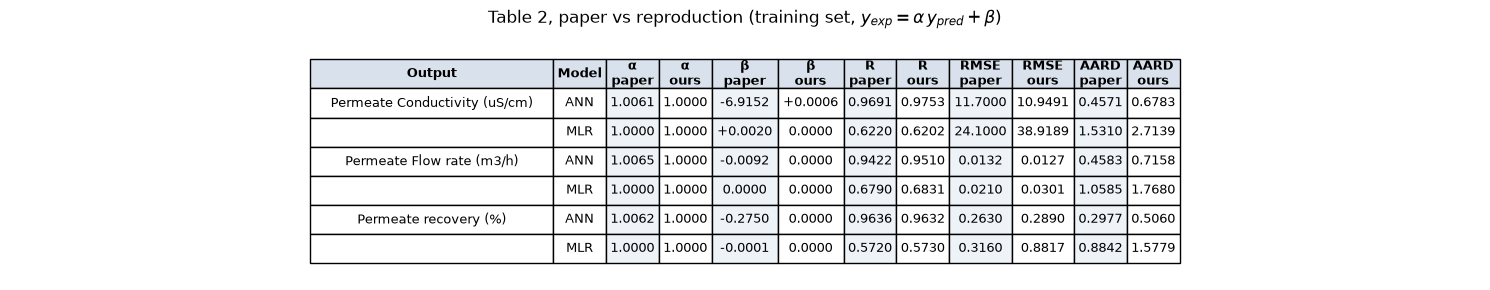

In [9]:
LABEL = {"PermeateConductivity": "Permeate Conductivity (uS/cm)",
         "PermeateFlowRate":     "Permeate Flow rate (m3/h)",
         "PermeateRecovery":     "Permeate recovery (%)"}
SHOW  = ["alpha", "beta", "R", "RMSE", "AARD"]

cmp = paper.merge(ours_train, on=["Output", "Model"], suffixes=(" paper", " ours"))
cmp["_k"] = cmp["Output"].map({o: i for i, o in enumerate(OUTPUTS)})
cmp = cmp.sort_values(["_k", "Model"]).drop(columns="_k").reset_index(drop=True)  # ANN, then MLR

pairs = [f"{m} {who}" for m in SHOW for who in ("paper", "ours")]
num   = cmp[["Output", "Model"] + pairs].copy()
num["Output"] = num["Output"].map(LABEL)

def _f(v, m):
    if m == "beta":
        return "0.0000" if abs(v) < 5e-5 else f"{v:+.4f}"
    return f"{v:.4f}"
disp = num.copy()
for m in SHOW:
    for who in ("paper", "ours"):
        disp[f"{m} {who}"] = disp[f"{m} {who}"].map(lambda v, m=m: _f(v, m))
disp.loc[disp.index % 2 == 1, "Output"] = ""

print("Table 2, paper vs ours (training set, 60 rows); fit line y_exp = alpha * y_pred + beta\n")
print(disp.to_string(index=False))
print()
print(f"alpha: max |paper - ours| over 6 rows = {(cmp['alpha paper'] - cmp['alpha ours']).abs().max():.4f}")
print(f"R:     max |paper - ours| over 6 rows = {(cmp['R paper'] - cmp['R ours']).abs().max():.4f}")

# same table as an image
fig, ax = plt.subplots(figsize=(15, 3.0)); ax.axis("off")
GLYPH = {"alpha": "α", "beta": "β", "R": "R", "RMSE": "RMSE", "AARD": "AARD"}
col_labels = ["Output", "Model"] + [f"{GLYPH[m]}\n{who}" for m in SHOW for who in ("paper", "ours")]
tbl = ax.table(cellText=disp.values.tolist(), colLabels=col_labels,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.7)
tbl.auto_set_column_width(list(range(len(col_labels))))
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(fontweight="bold"); cell.set_facecolor("#d9e2ec")
    elif c >= 2 and (c - 2) % 2 == 0:
        cell.set_facecolor("#eef3f8")
ax.set_title(r"Table 2, paper vs reproduction (training set, "
             r"$y_{exp} = \alpha\,y_{pred} + \beta$)", pad=14)
fig.tight_layout()
fig.savefig("table2_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

α and β: the three MLR rows give 1.0000 and 0.0000, as printed. This is exact for least squares,
and it also holds for the ANN at a converged fit. The paper's ANN rows print α ≈ 1.006, which a
converged in-sample fit cannot give. The likely cause is `trainlm` holding back part of the
training rows for early stopping, which our fit does not do.

R: within 0.009 on all six rows at this split (mean |ΔR| 0.004; at seed 42 the mean is 0.011 and the max 0.026). The MLR rows
have no random element and match almost exactly, which checks the data loading, column order and
scaling.

RMSE and AARD: see section 6. What is left of the differences comes from the unknown split, the
unreported `trainlm` settings and LM local minima.

## 8. Parity plots (Fig. 3 of the paper)

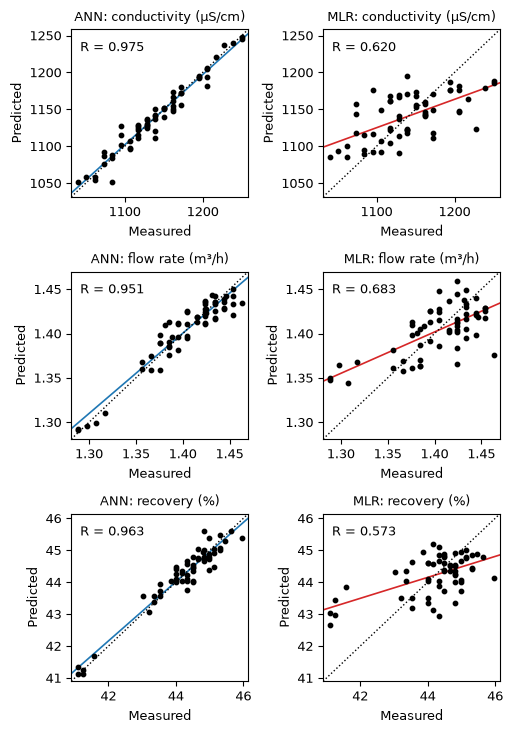

In [10]:
plt.rcParams.update({"font.size": 9})
NAME = {"PermeateConductivity": "conductivity (µS/cm)", "PermeateFlowRate": "flow rate (m³/h)",
        "PermeateRecovery": "recovery (%)"}

fig, axes = plt.subplots(3, 2, figsize=(5.2, 7.4))
truth = to_units(Y_train)
preds = {"ANN": to_units(ann.forward(X_train)), "MLR": to_units(mlr.predict(X_train))}

for r, out in enumerate(OUTPUTS):
    for c, model in enumerate(["ANN", "MLR"]):
        ax = axes[r, c]
        y, p = truth[out].values, preds[model][out].values
        lo, hi = min(y.min(), p.min()), max(y.max(), p.max()); pad = .04 * (hi - lo)
        a, b = np.polyfit(y, p, 1); xs = np.linspace(lo - pad, hi + pad, 100)
        ax.scatter(y, p, s=10, c="k", zorder=3)
        ax.plot(xs, a*xs + b, c="tab:blue" if model == "ANN" else "tab:red", lw=1.2)
        ax.plot(xs, xs, "k:", lw=1)
        ax.set_xlim(lo-pad, hi+pad); ax.set_ylim(lo-pad, hi+pad)
        ax.set_xlabel("Measured"); ax.set_ylabel("Predicted")
        ax.set_title(f"{model}: {NAME[out]}", fontsize=9)
        ax.text(.05, .87, f"R = {np.corrcoef(y,p)[0,1]:.3f}", transform=ax.transAxes)
fig.tight_layout()
plt.savefig("fig3_reproduction.png", dpi=300, bbox_inches="tight")
plt.savefig("fig3_reproduction.pdf", bbox_inches="tight")
plt.show()

## 9. Garson sensitivity (Fig. 5 of the paper)

Eq. (15). The paper shows one pie chart per output, so the hidden-to-output weights are taken one
output at a time.

In [11]:
def garson(net):
    W1, _, W2, _ = net.unpack(net.theta_)
    share = np.abs(W1) / np.abs(W1).sum(axis=1, keepdims=True)
    return pd.DataFrame({OUTPUTS[n]: 100 * (share * np.abs(W2[n])[:, None]).sum(0)
                                         / (share * np.abs(W2[n])[:, None]).sum()
                         for n in range(3)}, index=INPUTS).T

ours_imp = garson(ann).round(1)
paper_imp = pd.DataFrame([[19, 27, 16, 22, 16], [20, 31, 16, 18, 15], [19, 27, 16, 22, 16]],
                         index=OUTPUTS, columns=INPUTS)

print("Relative importance %, PAPER (Fig. 5):")
print(paper_imp.to_string())
print("\nRelative importance %, OURS:")
print(ours_imp.to_string())
print("\nNotebook 2 shows this ranking changes with the random seed.")

Relative importance %, PAPER (Fig. 5):
                      Time  Pressure  Temperature  FeedFlow  ConductivityFeed
PermeateConductivity    19        27           16        22                16
PermeateFlowRate        20        31           16        18                15
PermeateRecovery        19        27           16        22                16

Relative importance %, OURS:
                      Time  Pressure  Temperature  FeedFlow  ConductivityFeed
PermeateConductivity  41.8      18.3         19.5      12.1               8.3
PermeateFlowRate      35.2      20.2         21.9      14.7               8.0
PermeateRecovery      33.1      20.7         23.8      14.5               7.9

Notebook 2 shows this ranking changes with the random seed.


## 10. Save results

In [12]:
num.to_csv("table2_paper_vs_ours.csv", index=False)
pd.concat([ours_train.assign(Set="train"), ours_test.assign(Set="test")]).to_csv(
    "our_metrics.csv", index=False)
df.to_csv("table1_corrected.csv", index=False)
print("saved: table2_paper_vs_ours.csv, our_metrics.csv, table1_corrected.csv,")
print("       fig3_reproduction.png/.pdf, table2_comparison.png")

saved: table2_paper_vs_ours.csv, our_metrics.csv, table1_corrected.csv,
       fig3_reproduction.png/.pdf, table2_comparison.png


## Summary

The reproduction matches Table 2 on R (within 0.009 on all six rows) and on the MLR α and β.
Seven errors in the published paper:

1. Table 2, MLR rows: RMSE < MAE, which is impossible. The RMSE cells are the wrong ones
   (section 6). The ANN conductivity MAE cell is also wrong.
2. Table 2, AARD: a sum over the 60 training rows instead of the mean in Eq. (8).
3. Table 2 caption: gives y_pred = α·y_exp + β, but the printed α and β come from the reverse fit.
4. The text gives conductivity R = 0.98; Table 2 gives 0.9691.
5. The abstract gives recovery R = 0.963; Table 2 gives 0.9636 and the text 0.964.
6. The MLR equations (9)-(11) do not reproduce the paper's own MLR results.
7. Table 1, row 45: feed temperature 3.2915 °C (section 2).

Every value in Table 2 is in-sample. The paper sets aside 13 test rows but reports no result on
them. Notebook 2 scores the same model out-of-fold.